# 1. Config

First we need to import required modules and libraries. 

Note that while karpyoplot only requires pandas, numpy, and matplotlib, if you want to run this jupyter notebook, you will also need ipykernel and ipython

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.patches import Patch
import karpyoplot.karpyoplot as kp
from matplotlib.ticker import FuncFormatter
from IPython import get_ipython

get_ipython().run_line_magic("matplotlib", "inline")
get_ipython().run_line_magic(
    "config", "InlineBackend.figure_format = 'retina'"
)  # Improves display for high-res screens

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "Helvetica Neue"

pd.set_option("display.max_columns", 1000)

# 2. Define constants

There are a couple constants that we can define ahead of time that will be needed to plot ideograms.
- `cyto_colors`: Dictionary that maps stain names to hex color codes. This is used later map information in a `stain` column to a new `color` column in a cytoband df in `add_color_to_cyto()`.
- `chrom_order`: list of all 23 pairs of chromosomes (in humans!). Make sure that the items in this list match the same naming convention as the first column in your cytoband .bed/.tsv (i.e. "chr1" vs "1")

You don't *need* to use either of these, but it makes things easier.

In [2]:
CYTO_COLORS = {
    "gneg": "#ffffff",
    "gpos25": "#c6c6c6",
    "gpos50": "#999999",
    "gpos75": "#666666",
    "gpos100": "#000000",
    "acen": "#cc6666",
    "gvar": "#cccccc",
    "stalk": "#e6e6e6",
}

# human genome!
CHROM_ORDER = [f"chr{i}" for i in list(range(1, 23)) + ["X", "Y"]]

# 3. Load cytobands

The main data source karpyoplot uses to make the ideogram is a cytoband file. Currently it is only tested on the hg38 and chm13v2.0 cytobands downloaded from the ucsc genome browser, but in theory any bed file with `chrom`, `start`, and `stop` columns should work. Installing the package automatically installs the hg38 and chm13v2.0 cytoband files, but you can also read in your own bed file.

In [3]:
# load from options installed with package
hg38 = kp.load_cytobands(genome="hg38")

# load from your own file
chm13 = pd.read_csv(
    "example_data/chm13v2.0_cytobands_allchrs.bed",
    sep="\t",
    header=None,
    names=["chrom", "start", "stop", "band", "stain"],
)

Now we can use the `cyto_colors` dictionary to add a new `color` column based on the values in the `stain` column. You can use the `add_color_to_cyto()` function, which takes a mapping dictionary as input along with a column in your cytoband df to create the new color column. 

Alternatively, you can add a simple default color column if you don't want to display any extra information within the chromosome bodies.

In [4]:
kp.add_color_to_cyto(chm13, color_map=CYTO_COLORS, map_col="stain", color_col="color")
# kp.add_color_to_bed(chm13, color='#4c72b0', color_col='color')

,chrom,start,stop,band,stain,color
0,chr1,0,1735965,p36.33,gneg,#ffffff
1,chr1,1735965,4816989,p36.32,gpos25,#c6c6c6
2,chr1,4816989,6629068,p36.31,gneg,#ffffff
3,chr1,6629068,8634052,p36.23,gpos25,#c6c6c6
4,chr1,8634052,12044143,p36.22,gneg,#ffffff
...,...,...,...,...,...,...
857,chrY,13307633,18006518,q11.221,gpos50,#999999
858,chrY,18006518,20506564,q11.222,gneg,#ffffff
859,chrY,20506564,25062557,q11.223,gpos50,#999999
860,chrY,25062557,27449937,q11.23,gneg,#ffffff


In [5]:
chm13 = kp.add_color_to_cyto(
    chm13, color_map=CYTO_COLORS, map_col="stain", color_col="color"
)

Again, this cytoband df is what karpyoplot uses to draw chromosomes (or whatever contigs are in your bed file)

# 4. Plot ideogram

To plot the ideogram, create a `layout` object with the `Ideogram` class and plot it on a matplotlib fig, ax.

First decide which chromosomes you want to include (or include all of them!)

In [6]:
chroms = [c for c in CHROM_ORDER if c in chm13["chrom"].unique()]
# chroms = ["chr12", 'chr17']
chrom_lengths = chm13.groupby("chrom")["stop"].max()

`chroms` is a list of chromosomes that you can define. Here it is just all the chromosomes present in the `CHROM_ORDER` constant from before that are also present in your cytoband file. Alternatively, you could just populate this list with whatever chromosomes you actually want to plot. This will be used when we create the ideogram object to define which chroms should be present
`chrom_lengths` is a pandas series that just stores the total length of each chromosome in your cytoband df. It will be used later to scale the x axis

Now we can actually make the ideogram object

In [7]:
chm13_layout = kp.Ideogram(
    chroms=chroms,
    n_tracks_above=0,
    n_tracks_below=0,
    chrom_height=0.6,
    track_height=0.25,
    track_gap=0.15,
    chrom_track_gap=0.15,
    row_gap=0.7,
)

See ___ for an explanation of how all these parameters and spacing items work. Briefly
- `n_tracks_above` defines how many tracks you want above each chromosome
- `n_tracks_below` defines how many tracks you want below each chromosome
- `chrom_height` defines how "tall" each chromosome should be
- `track_height` defines how "tall" each track should be. There is currently not a way to set this at a per-track level (but will be added soon)
- `track_gap` defines how much space there should be between track items
- `chrom_track_gap` defines how much space there should be between the chromosome and the first track above and below it
- `row_gap` defines how much space there should be between each chromosome + track(s) elements

Now create the figure and axes on which to plot and use the `plot_ideogram()` function actually create the figure. Extra information can be added to prettify the plot

Text(0.5, 1.0, 'chm13v2.0 ideogram')

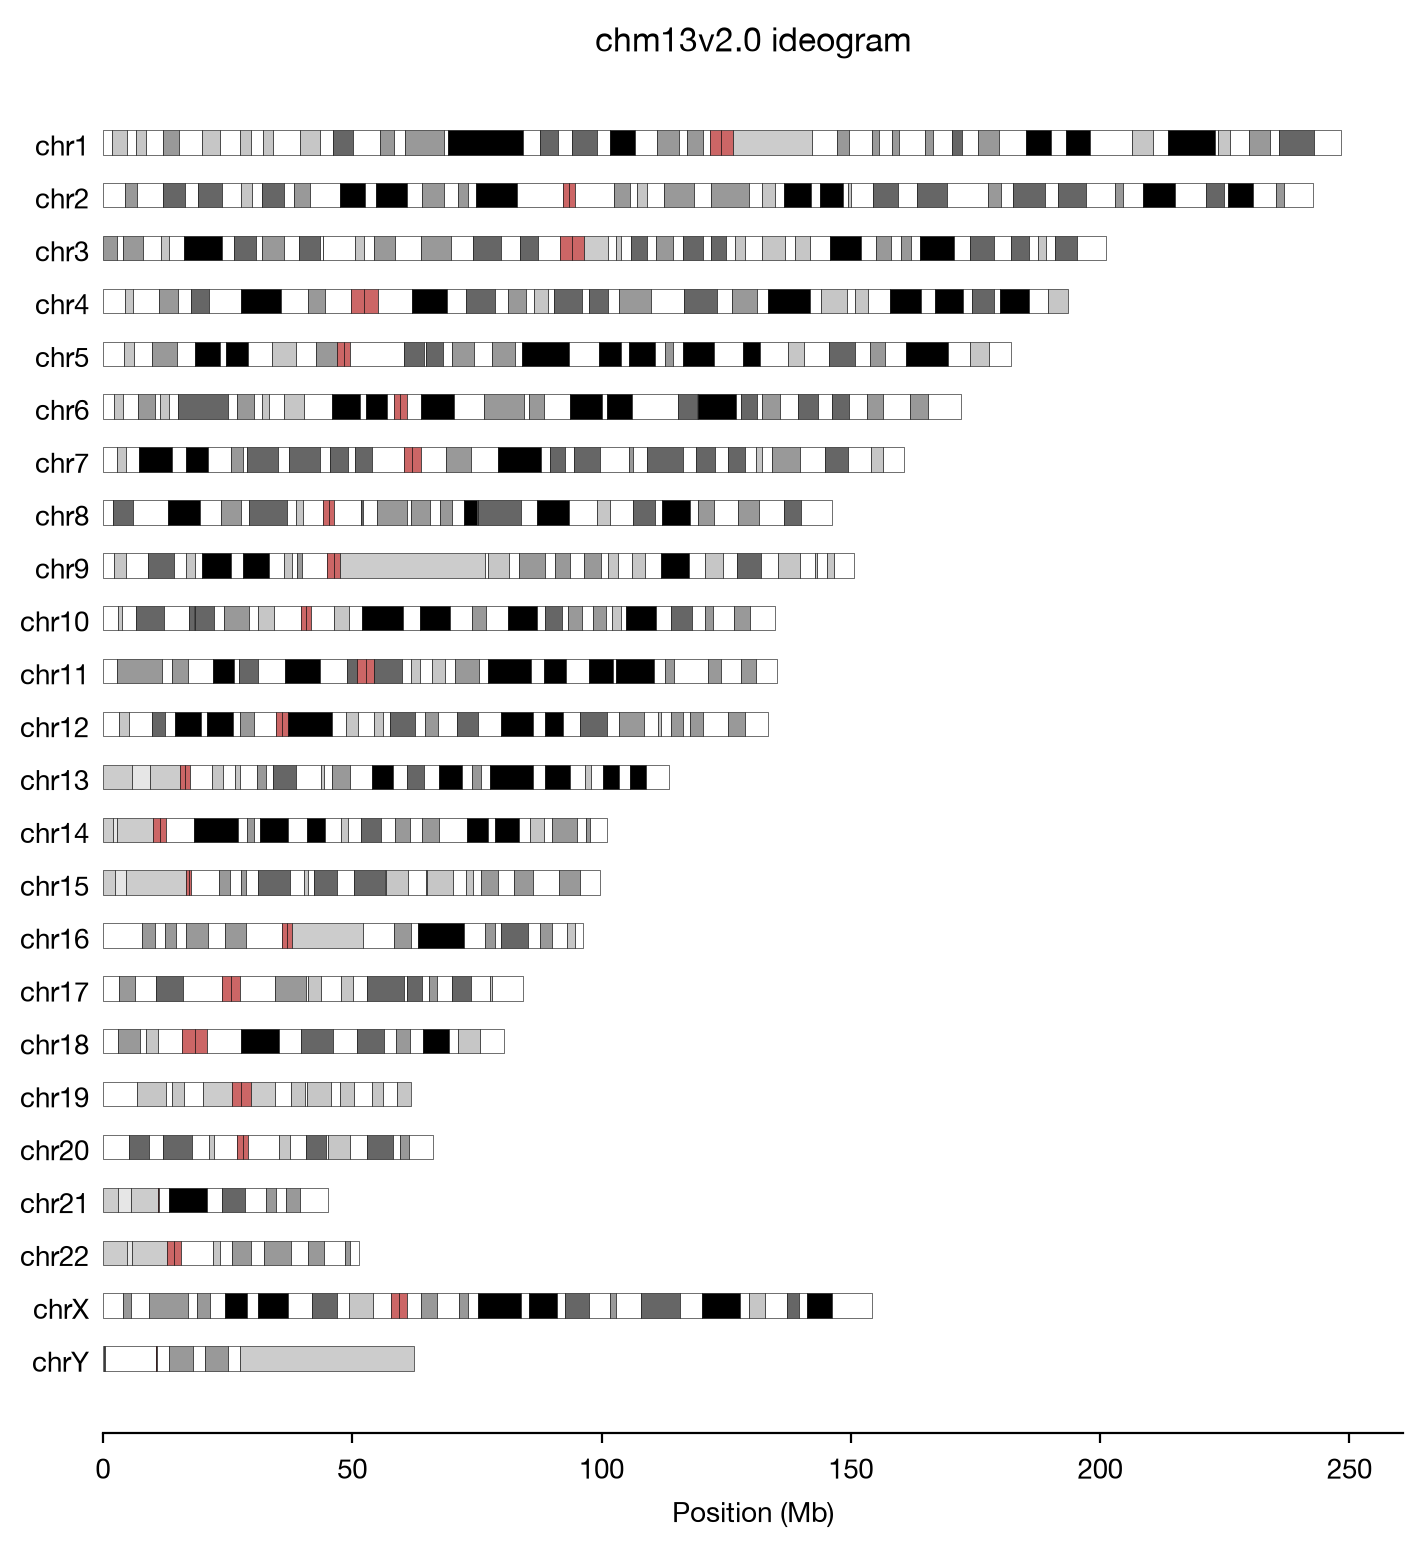

In [8]:
fig, ax = plt.subplots(
    1, 1, figsize=(7, 0.25 * chm13_layout.total_height), layout="constrained"
)

kp.plot_ideogram(ax=ax, cyto=chm13, layout=chm13_layout, chrom_col="chrom")

# invert yaxis so we get chr1 - chrY top to bottom
ax.invert_yaxis()

# get ytick and label marks (whatever was in the first col of your bed file)
yticks, ylabels = chm13_layout.yticks_and_labels
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=10)
ax.tick_params(
    axis="y",
    length=0,  # tick connecting ylabel to chromosome
    pad=5,  # add a small gap between the ylabel and the leftmost end of the chromosome
)

# remove top, left, and right spines
for spine in [
    "top",
    "right",
    "left",
]:
    ax.spines[spine].set_visible(False)

# modify plot xlims so it looks better
ax.set_xlim(
    0,
    chrom_lengths[chm13_layout.chroms].max()
    * 1.05,  # multiply by 1.05 to make sure there's a little extra space on the right
)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.0f}"))  # format as Mb
ax.set_xlabel("Position (Mb)")
ax.set_title("chm13v2.0 ideogram")